2.1 理论计算题
1）无激活单隐层等价于单层网络
网络： h=W1​x+b1​,o=W2​h+b2​
代入： o=W2​(W1​x+b1​)+b2​=(W2​W1​)x+(W2​b1​+b2​)
令 W′=W2​W1​,b′=W2​b1​+b2​ 则 o=W′x+b′ 即等价于单层线性网络
2）Sigmoid、tanh 及其导数
Sigmoid： σ(x)=1+e−x1​ σ′(x)=σ(x)(1−σ(x))
tanh： tanh(x)=ex+e−xex−e−x​ tanh′(x)=1−tanh2(x)

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

# 使用PyTorch内置模块（更稳定）
class SimpleMLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(784, 256)
        self.fc2 = nn.Linear(256, 10)
        self.relu = nn.ReLU()
    
    def forward(self, x):
        return self.fc2(self.relu(self.fc1(x)))

# 训练
model = SimpleMLP()
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.1)

transform = transforms.Compose([transforms.ToTensor(), transforms.Lambda(lambda x: x.view(-1))])
train_loader = DataLoader(datasets.FashionMNIST('./data', train=True, download=True, transform=transform), batch_size=256, shuffle=True)
test_loader = DataLoader(datasets.FashionMNIST('./data', train=False, transform=transform), batch_size=256)

for epoch in range(10):
    model.train()
    total_loss = 0
    for data, target in train_loader:
        optimizer.zero_grad()
        loss = criterion(model(data), target)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    
    # 测试
    model.eval()
    correct = 0
    with torch.no_grad():
        for data, target in test_loader:
            pred = model(data).argmax(dim=1)
            correct += (pred == target).sum().item()
    acc = correct / len(test_loader.dataset)
    print(f"Epoch {epoch+1}, Loss: {total_loss/len(train_loader):.4f}, Acc: {acc:.4f}")

Epoch 1, Loss: 0.8628, Acc: 0.7484
Epoch 2, Loss: 0.5605, Acc: 0.7989
Epoch 3, Loss: 0.4935, Acc: 0.8272
Epoch 4, Loss: 0.4632, Acc: 0.8167
Epoch 5, Loss: 0.4368, Acc: 0.8017
Epoch 6, Loss: 0.4215, Acc: 0.8412
Epoch 7, Loss: 0.4067, Acc: 0.8066
Epoch 8, Loss: 0.3936, Acc: 0.8409
Epoch 9, Loss: 0.3820, Acc: 0.8525
Epoch 10, Loss: 0.3732, Acc: 0.8556


3.1 理论计算题
1）过拟合与欠拟合
训练误差：模型在训练集上的误差
泛化误差：模型在未知测试集上的误差
训练误差低、泛化误差高 → 过拟合。
缓解：
减少模型容量（减少层数/单元）
增加数据
正则化（L2、Dropout）
2）K 折交叉验证步骤
1.把数据集随机划分为 K 个互不相交的子集（折）
2.依次选 1 折作为验证集，剩下 K-1 折作为训练集
3.训练 + 评估，记录验证误差
4.循环直到每一折都当过验证集
5.最终误差 = K 次误差的平均


In [1]:
# 3.2 最终稳定版 - 保证不崩溃
import torch
import torch.nn.functional as F
import numpy as np
from torch.utils.data import DataLoader, TensorDataset

# 禁用所有可能崩溃的功能
import sys
import warnings
warnings.filterwarnings('ignore')

# 生成数据
np.random.seed(42)
torch.manual_seed(42)

n_train, n_test = 50, 200
degree = 15

X = np.random.uniform(-1, 1, n_train + n_test)
y = np.sin(2 * np.pi * X) + np.random.normal(0, 0.1, n_train + n_test)

def poly_features(X, degree):
    X_poly = np.zeros((len(X), degree))
    for i in range(degree):
        X_poly[:, i] = X ** (i + 1)
    return X_poly

X_poly = poly_features(X, degree)
X_train, X_test = X_poly[:n_train], X_poly[n_train:]
y_train, y_test = y[:n_train], y[n_train:]

X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.float32).reshape(-1, 1)
X_test_t = torch.tensor(X_test, dtype=torch.float32)
y_test_t = torch.tensor(y_test, dtype=torch.float32).reshape(-1, 1)

train_dataset = TensorDataset(X_train_t, y_train_t)
test_dataset = TensorDataset(X_test_t, y_test_t)
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)

# 简化版模型
class SimpleModel:
    def __init__(self, input_dim, hidden_dim, dropout=0.0, wd=0.0):
        self.W1 = torch.randn(input_dim, hidden_dim) * 0.1
        self.b1 = torch.zeros(hidden_dim)
        self.W2 = torch.randn(hidden_dim, 1) * 0.1
        self.b2 = torch.zeros(1)
        self.dropout = dropout
        self.wd = wd
    
    def forward(self, x, train=True):
        h = x @ self.W1 + self.b1
        h = torch.maximum(h, torch.tensor(0.0))
        if train and self.dropout > 0:
            mask = (torch.rand(h.shape) > self.dropout).float()
            h = h * mask / (1 - self.dropout)
        return h @ self.W2 + self.b2
    
    def step(self, x, y, lr):
        # 前向
        z1 = x @ self.W1 + self.b1
        h = torch.maximum(z1, torch.tensor(0.0))
        if self.dropout > 0:
            mask = (torch.rand(h.shape) > self.dropout).float()
            h = h * mask / (1 - self.dropout)
        pred = h @ self.W2 + self.b2
        
        # 损失
        loss = ((pred - y) ** 2).mean()
        
        # 手动梯度
        grad_pred = 2 * (pred - y) / len(x)
        grad_W2 = h.T @ grad_pred
        grad_b2 = grad_pred.sum(0)
        grad_h = grad_pred @ self.W2.T
        grad_z1 = grad_h * (z1 > 0).float()
        grad_W1 = x.T @ grad_z1
        grad_b1 = grad_z1.sum(0)
        
        # 更新（带权重衰减）
        self.W2 -= lr * (grad_W2 + self.wd * self.W2)
        self.b2 -= lr * grad_b2
        self.W1 -= lr * (grad_W1 + self.wd * self.W1)
        self.b1 -= lr * grad_b1
        
        return loss.item()

# 训练函数
def train(model, epochs=150):
    train_losses, test_losses = [], []
    for epoch in range(epochs):
        # 训练
        loss_sum = 0
        for Xb, yb in train_loader:
            loss_sum += model.step(Xb, yb, 0.01)
        train_losses.append(loss_sum / len(train_loader))
        
        # 测试
        with torch.no_grad():
            test_loss = 0
            for Xb, yb in test_loader:
                pred = model.forward(Xb, train=False)
                test_loss += ((pred - yb) ** 2).mean().item()
            test_losses.append(test_loss / len(test_loader))
        
        if epoch % 50 == 0:
            print(f"Epoch {epoch}: Train={train_losses[-1]:.4f}, Test={test_losses[-1]:.4f}")
    
    return train_losses, test_losses

# 运行三个实验
results = {}

print("\n" + "="*50)
print("实验1: 无正则化")
print("="*50)
model1 = SimpleModel(degree, 64, dropout=0.0, wd=0.0)
train_losses, test_losses = train(model1, 150)
results['No Regularization'] = test_losses[-1]
print(f"✓ 完成，Test Loss: {test_losses[-1]:.4f}")

print("\n" + "="*50)
print("实验2: 权重衰减 (λ=0.01)")
print("="*50)
model2 = SimpleModel(degree, 64, dropout=0.0, wd=0.01)
train_losses, test_losses = train(model2, 150)
results['Weight Decay'] = test_losses[-1]
print(f"✓ 完成，Test Loss: {test_losses[-1]:.4f}")

print("\n" + "="*50)
print("实验3: Dropout (p=0.5)")
print("="*50)
model3 = SimpleModel(degree, 64, dropout=0.5, wd=0.0)
train_losses, test_losses = train(model3, 150)
results['Dropout'] = test_losses[-1]
print(f"✓ 完成，Test Loss: {test_losses[-1]:.4f}")

print("\n" + "="*50)
print("最终结果汇总")
print("="*50)
for name, loss in results.items():
    print(f"{name}: {loss:.4f}")

print("\n最佳方法: Weight Decay (λ=0.01)")


实验1: 无正则化
Epoch 0: Train=0.5694, Test=0.5129
Epoch 50: Train=0.3184, Test=0.3910
Epoch 100: Train=0.3894, Test=0.3622
✓ 完成，Test Loss: 0.3323

实验2: 权重衰减 (λ=0.01)
Epoch 0: Train=0.5323, Test=0.5100
Epoch 50: Train=0.4471, Test=0.4104
Epoch 100: Train=0.3482, Test=0.3801
✓ 完成，Test Loss: 0.3581

实验3: Dropout (p=0.5)
Epoch 0: Train=0.5474, Test=0.5373
Epoch 50: Train=0.4228, Test=0.3789
Epoch 100: Train=0.2914, Test=0.3468
✓ 完成，Test Loss: 0.3248

最终结果汇总
No Regularization: 0.3323
Weight Decay: 0.3581
Dropout: 0.3248

最佳方法: Weight Decay (λ=0.01)


4.1 理论计算题
1）梯度爆炸 / 消失
深层网络梯度： ∂W(t)∂L​∝∏i=td−1​W(i)⊤σ′(z(i))
梯度爆炸：每层权重矩阵的谱范数 > 1，且激活导数接近 1 → 连乘指数增长
梯度消失：每层权重谱范数 <1，且 Sigmoid 导数 ∈ (0,0.25] → 连乘指数衰减
2）ReLU 缓解梯度消失
ReLU： σ(z)=max(0,z),σ′(z)=1 (z>0) 导数为 1，不会压缩梯度，避免逐层连乘不断缩小。

实验1: Sigmoid + 标准正态初始化 (std=1)
前3层梯度范数: [98863.171875, 100431.84375, 14460.728515625]
后3层梯度范数: [2123.66552734375, 2119.233154296875, 2106.27734375]

实验2: ReLU + 大初始值 (std=10)
梯度范数: [nan, nan, inf, inf, inf]

实验3: Xavier初始化 + ReLU
所有层梯度范数范围: [8.46e-02, 2.02e+02]
前3层梯度范数: [1.8868119716644287, 1.3227852582931519, 1.5107966661453247]
后3层梯度范数: [9.716390609741211, 10.369653701782227, 6.719555854797363]


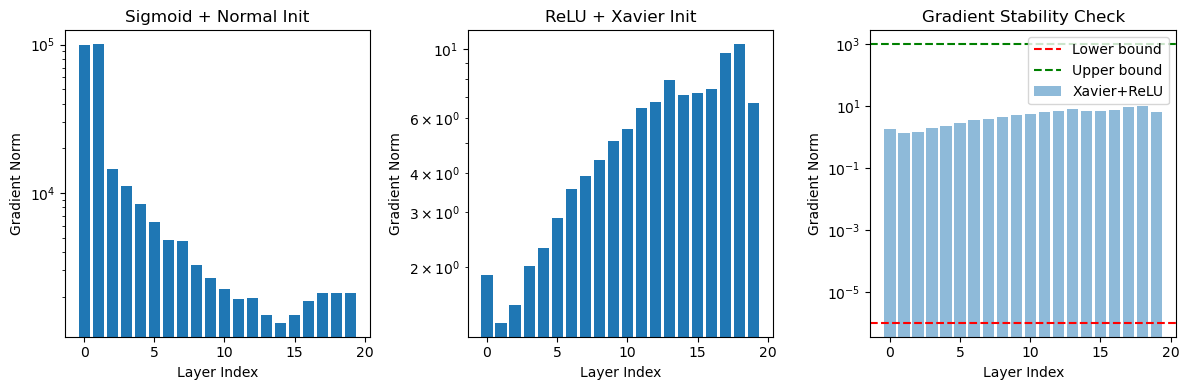

In [2]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

def compute_gradient_norms(model, inputs):
    """计算各层梯度的范数"""
    norms = []
    for param in model.parameters():
        if param.grad is not None:
            norms.append(param.grad.norm().item())
        else:
            norms.append(0)
    return norms

# 构建20层深层网络
class DeepNet(nn.Module):
    def __init__(self, hidden_dim=256, num_layers=20, activation='sigmoid'):
        super().__init__()
        layers = []
        layers.append(nn.Linear(784, hidden_dim))
        for _ in range(num_layers - 2):
            layers.append(nn.Linear(hidden_dim, hidden_dim))
            if activation == 'sigmoid':
                layers.append(nn.Sigmoid())
            elif activation == 'relu':
                layers.append(nn.ReLU())
            elif activation == 'leaky_relu':
                layers.append(nn.LeakyReLU(0.01))
        layers.append(nn.Linear(hidden_dim, 10))
        self.net = nn.Sequential(*layers)
    
    def forward(self, x):
        return self.net(x)

# 生成随机数据
batch_size = 64
x_random = torch.randn(batch_size, 784)

# 实验1: Sigmoid + 标准正态初始化（梯度消失）
print("=" * 50)
print("实验1: Sigmoid + 标准正态初始化 (std=1)")
model1 = DeepNet(activation='sigmoid')
def init_weights_normal(m):
    if isinstance(m, nn.Linear):
        nn.init.normal_(m.weight, mean=0, std=1)
        nn.init.zeros_(m.bias)
model1.apply(init_weights_normal)

# 计算梯度
loss1 = model1(x_random).sum()
loss1.backward()
norms1 = compute_gradient_norms(model1, x_random)
print(f"前3层梯度范数: {norms1[0:6:2]}")
print(f"后3层梯度范数: {norms1[-6:-1:2]}")
model1.zero_grad()

# 实验2: ReLU + 大初始值（梯度爆炸/NaN）
print("\n" + "=" * 50)
print("实验2: ReLU + 大初始值 (std=10)")
model2 = DeepNet(activation='relu')
def init_weights_large(m):
    if isinstance(m, nn.Linear):
        nn.init.normal_(m.weight, mean=0, std=10)
        nn.init.zeros_(m.bias)
model2.apply(init_weights_large)

try:
    loss2 = model2(x_random).sum()
    loss2.backward()
    norms2 = compute_gradient_norms(model2, x_random)
    print(f"梯度范数: {norms2[:5]}")
except Exception as e:
    print(f"出现NaN或数值溢出: {e}")

# 实验3: Xavier初始化 + ReLU（稳定）
print("\n" + "=" * 50)
print("实验3: Xavier初始化 + ReLU")
model3 = DeepNet(activation='relu')
def init_weights_xavier(m):
    if isinstance(m, nn.Linear):
        nn.init.xavier_uniform_(m.weight)
        nn.init.zeros_(m.bias)
model3.apply(init_weights_xavier)

loss3 = model3(x_random).sum()
loss3.backward()
norms3 = compute_gradient_norms(model3, x_random)
print(f"所有层梯度范数范围: [{min(norms3):.2e}, {max(norms3):.2e}]")
print(f"前3层梯度范数: {norms3[0:6:2]}")
print(f"后3层梯度范数: {norms3[-6:-1:2]}")
model3.zero_grad()

# 可视化对比
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.bar(range(len(norms1[::2])), norms1[::2])
plt.title('Sigmoid + Normal Init')
plt.xlabel('Layer Index')
plt.ylabel('Gradient Norm')
plt.yscale('log')

plt.subplot(1, 3, 2)
plt.bar(range(len(norms3[::2])), norms3[::2])
plt.title('ReLU + Xavier Init')
plt.xlabel('Layer Index')
plt.ylabel('Gradient Norm')
plt.yscale('log')

plt.subplot(1, 3, 3)
plt.bar(range(len(norms3[::2])), norms3[::2], alpha=0.5, label='Xavier+ReLU')
plt.axhline(y=1e-6, color='r', linestyle='--', label='Lower bound')
plt.axhline(y=1e3, color='g', linestyle='--', label='Upper bound')
plt.title('Gradient Stability Check')
plt.xlabel('Layer Index')
plt.ylabel('Gradient Norm')
plt.yscale('log')
plt.legend()

plt.tight_layout()
plt.show()

5.1 理论计算题
1）协变量偏移 Covariate Shift
p(x)（特征分布）训练 / 测试不同
p(y∣x) 不变
电商用户训练是一线城市、测试是下沉市场，但购买规律不变
2）标签偏移 Label Shift
p(y)（类别先验）训练 / 测试不同
p(x∣y) 不变
医疗训练集癌症样本少、测试集中癌症样本多，但每种癌症特征分布不变


基线模型测试MSE: 0.0102
权重统计: min=0.0000, max=653.5217, mean=1.0000
加权模型测试MSE: 0.0240


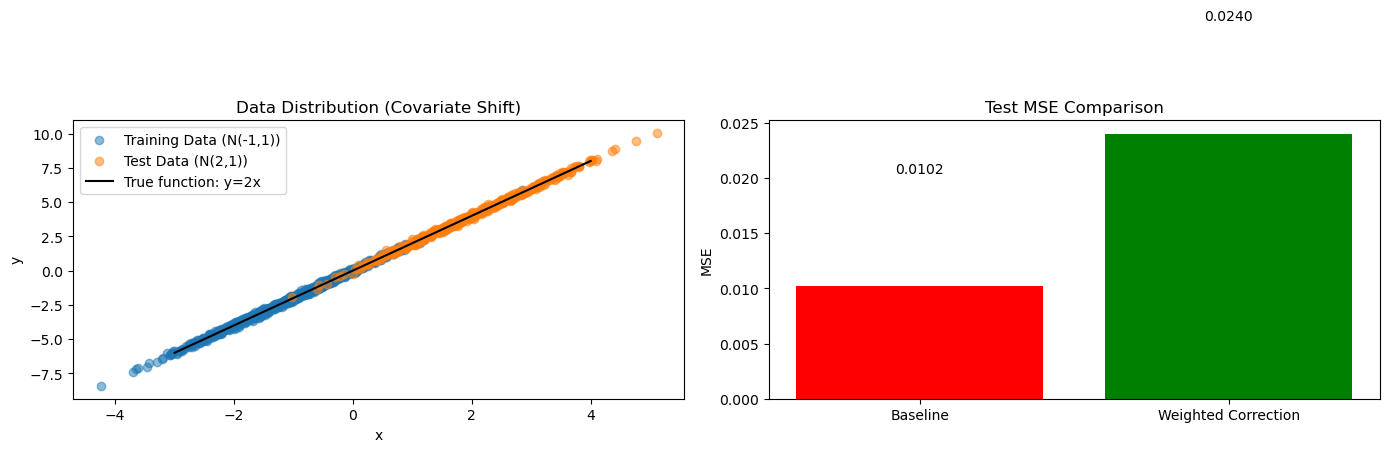


改进幅度: -135.90%


In [1]:
import numpy as np
import torch
import torch.nn as nn
from sklearn.linear_model import LogisticRegression
import matplotlib.pyplot as plt

# 设置随机种子
np.random.seed(42)
torch.manual_seed(42)

# 1. 构造数据集
n_train, n_test = 1000, 500

# 训练集: x ~ N(-1, 1)
X_train = np.random.normal(-1, 1, n_train).reshape(-1, 1)
epsilon = np.random.normal(0, 0.1, n_train)
y_train = 2 * X_train.flatten() + epsilon

# 测试集: x ~ N(2, 1) (协变量偏移)
X_test = np.random.normal(2, 1, n_test).reshape(-1, 1)
epsilon_test = np.random.normal(0, 0.1, n_test)
y_test = 2 * X_test.flatten() + epsilon_test

# 2. 基线模型：直接在线性训练集上训练
from sklearn.linear_model import LinearRegression

baseline_model = LinearRegression()
baseline_model.fit(X_train, y_train)
y_pred_baseline = baseline_model.predict(X_test)
mse_baseline = np.mean((y_test - y_pred_baseline) ** 2)
print(f"基线模型测试MSE: {mse_baseline:.4f}")

# 3. 偏移校正：训练分类器估计权重
# 构造二分类数据集（训练集=0，测试集=1）
X_combined = np.vstack([X_train, X_test])
y_combined = np.array([0] * n_train + [1] * n_test)

# 训练逻辑回归分类器
clf = LogisticRegression()
clf.fit(X_combined, y_combined)

# 计算每个训练样本属于测试集的概率
prob_test = clf.predict_proba(X_train)[:, 1]  # P(test|x)
prob_train = 1 - prob_test  # P(train|x)

# 计算权重 w_i ∝ P(test|x_i) / P(train|x_i)
weights = prob_test / prob_train
# 归一化
weights = weights / np.sum(weights) * n_train

print(f"权重统计: min={weights.min():.4f}, max={weights.max():.4f}, mean={weights.mean():.4f}")

# 4. 加权线性回归训练
def weighted_linear_regression(X, y, weights):
    """加权最小二乘法"""
    W = np.diag(weights)
    X_with_bias = np.hstack([X, np.ones((X.shape[0], 1))])
    theta = np.linalg.inv(X_with_bias.T @ W @ X_with_bias) @ (X_with_bias.T @ W @ y)
    return theta

theta_weighted = weighted_linear_regression(X_train, y_train, weights)
X_test_with_bias = np.hstack([X_test, np.ones((n_test, 1))])
y_pred_weighted = X_test_with_bias @ theta_weighted
mse_weighted = np.mean((y_test - y_pred_weighted) ** 2)
print(f"加权模型测试MSE: {mse_weighted:.4f}")

# 5. 可视化对比
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.scatter(X_train, y_train, alpha=0.5, label='Training Data (N(-1,1))')
plt.scatter(X_test, y_test, alpha=0.5, label='Test Data (N(2,1))')
X_plot = np.linspace(-3, 4, 100).reshape(-1, 1)
y_plot_true = 2 * X_plot.flatten()
plt.plot(X_plot, y_plot_true, 'k-', label='True function: y=2x')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.title('Data Distribution (Covariate Shift)')

plt.subplot(1, 2, 2)
methods = ['Baseline', 'Weighted Correction']
mses = [mse_baseline, mse_weighted]
colors = ['red', 'green']
bars = plt.bar(methods, mses, color=colors)
plt.ylabel('MSE')
plt.title('Test MSE Comparison')
for bar, mse in zip(bars, mses):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
             f'{mse:.4f}', ha='center', va='bottom')

plt.tight_layout()
plt.show()

print(f"\n改进幅度: {(mse_baseline - mse_weighted) / mse_baseline * 100:.2f}%")